# F500 Problem Set 1

## Exercice 1

First obtain daily price data on a stock index and two individual stocks from a market of your choice. The method for assignment is given below. The calculations can be performed in Excel and/or Eviews, but also in other software packages, as you prefer.

### 1.a)

Compute the sample statistics of the stock return (computed from the daily closing price) series, i.e., the mean, standard deviation, skewness and kurtosis. You may ignore dividends and just focus on capital gain.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns


The two stocks I am analysing are from the SMI. I will analyse UBS stocks and Lonza stocks.
I am downloading 10 years of daily data.

The columns of the dataset are:

- open: price at which the stock first traded when the market opened that day (reflects overnight information)
- high: highest transaction price reached during that trading day
- low: lowest transaction price during that trading day
- close: final traded price at market close
- adj close: closing price adjusted for dividends, stock splits and corporate actions (reflects the true capital gain including reinvested dividends)
- volume: number of shares during the day



In [2]:
tickers = ["UBSG.SW", "LONN.SW", "^SSMI"]

df = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-01-01",
    interval="1d",
    auto_adjust=False
)


[*********************100%***********************]  3 of 3 completed


In [3]:
# Compute daily simple returns from closing prices (ignoring dividends)
close = df['Close']
returns = close.pct_change().dropna()

# pct_change() is build in pandas and computes the percentage change between consecutive rows.
# r_t = (P_t - P_{t-1}) / P_{t-1}

# skew() is a measure of asymmetry
# kurtosis() measures howw heavy are the tails compared to a normal distribution.

# Sample statistics
stats = pd.DataFrame({
    "Mean": returns.mean(),
    "Std Dev": returns.std(),
    "Skewness": returns.skew(),
    "Kurtosis (Excess)": returns.kurtosis()
})

print(stats)


             Mean   Std Dev  Skewness  Kurtosis (Excess)
Ticker                                                  
LONN.SW  0.000814  0.018179 -0.811812          11.725187
UBSG.SW  0.000377  0.018465 -0.343690           6.607814
^SSMI    0.000146  0.009623 -0.854113          10.328708


We are studying returns, not prices. Raw prices are not directly comparable across stocks. Percentages normalize it and gives a rate of return that is comparable and unit free.

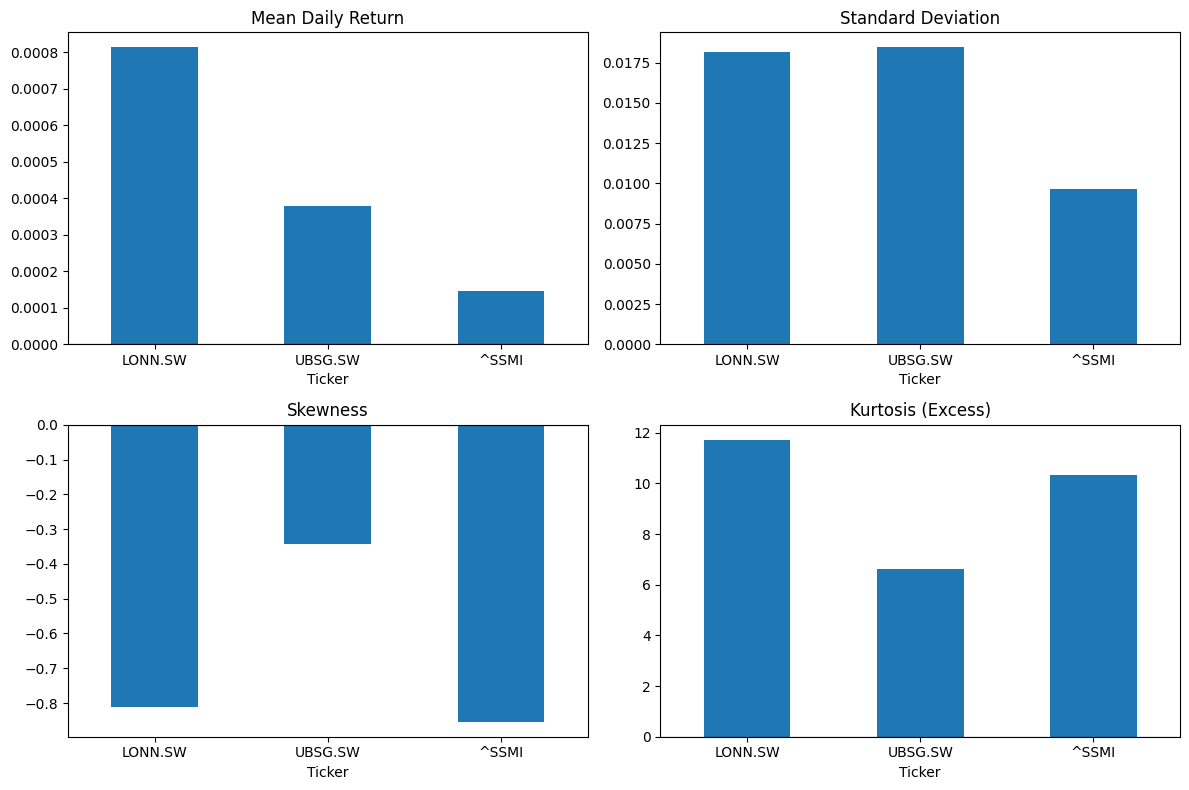

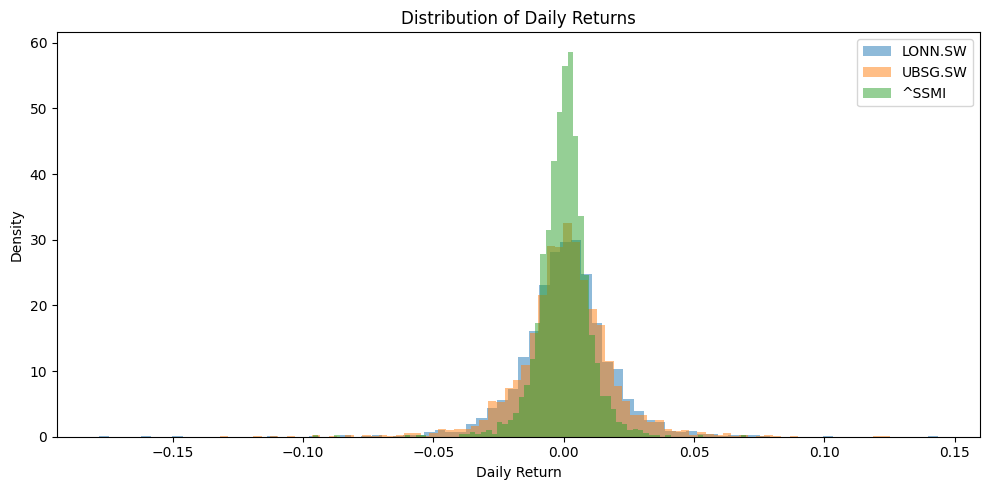

In [5]:
# Bar charts comparing summary statistics across the three series
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

stats['Mean'].plot(kind='bar', ax=axes[0, 0], title='Mean Daily Return')
axes[0, 0].axhline(0, color='k', linewidth=0.8)

stats['Std Dev'].plot(kind='bar', ax=axes[0, 1], title='Standard Deviation')

stats['Skewness'].plot(kind='bar', ax=axes[1, 0], title='Skewness')
axes[1, 0].axhline(0, color='k', linewidth=0.8)

stats['Kurtosis (Excess)'].plot(kind='bar', ax=axes[1, 1], title='Kurtosis (Excess)')
axes[1, 1].axhline(0, color='k', linewidth=0.8)

for ax in axes.flat:
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Overlaid histograms to compare return distributions
fig, ax = plt.subplots(figsize=(10, 5))
for col in returns.columns:
    ax.hist(returns[col], bins=80, alpha=0.5, label=col, density=True)
ax.set_xlabel('Daily Return')
ax.set_ylabel('Density')
ax.set_title('Distribution of Daily Returns')
ax.legend()
plt.tight_layout()
plt.show()



Lonza has the highest mean daily return, but also high volatility.
UBS has moderate return but with a similar volatility to Lonza.
SMI has the lowest return but also a much lowest volatility.

The skewness is negative for all stocks, which show that they usually have more frequent large negative returns than positive ones.

The fat tails indicate that extreme events occur much more frequently than a normal distribution would predict.